# Tuần 4 - Lê Quốc Bảo - Error Analysis

Notebook này dùng để phân tích 10 query mà phương pháp chính trả sai hoàn toàn (`AP = 0`) và xuất file:

```text
results/error_analysis.csv
```

Notebook ưu tiên đọc output của pipeline Strong Fusion:

```text
STRONG_best_detail_*.csv
STRONG_best_top_indices_*.npy
candidate_df_strong_yolo_crop_fusion.csv
```

Nếu project dùng output Two-Stage cũ hoặc Fusion cũ, notebook vẫn cố tự tìm các file tương thích.


In [1]:
from pathlib import Path
import os
import re
import json
import math
import warnings
from typing import Optional, List, Dict, Any

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, UnidentifiedImageError
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# ============================================================
# 1) Cấu hình thủ công nếu notebook không tự tìm đúng file
# ============================================================
MANUAL_DETAIL_CSV = r"E:\study\DoAnPython\project\results\STRONG_best_detail_StrongFusion_global_crop_text_light_crop_phash_strong.csv"
MANUAL_TOP_NPY = r"E:\study\DoAnPython\project\data\processed\STRONG_best_top_indices_StrongFusion_global_crop_text_light_crop_phash_strong.npy"
MANUAL_CANDIDATE_CSV = r"E:\study\DoAnPython\project\data\processed\candidate_df_strong_yolo_crop_fusion.csv"
MANUAL_IMAGE_DIR = r"E:\study\DoAnPython\project\data\raw\train_images"

# Ví dụ:
# MANUAL_DETAIL_CSV = r"../results/STRONG_best_detail_xxx.csv"
# MANUAL_TOP_NPY = r"../data/processed/STRONG_best_top_indices_xxx.npy"
# MANUAL_CANDIDATE_CSV = r"../data/processed/candidate_df_strong_yolo_crop_fusion.csv"
# MANUAL_IMAGE_DIR = r"../data/raw/train_images"

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "../results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR :", RESULTS_DIR)


PROJECT_ROOT: e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\notebooks
RESULTS_DIR : e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\notebooks\..\results


In [2]:
# ============================================================
# 2) Hàm tìm file output trong project
# ============================================================
def existing_path(p):
    if p is None:
        return None
    p = Path(p)
    return p if p.exists() else None


def unique_existing_dirs(dirs):
    out = []
    seen = set()
    for d in dirs:
        d = Path(d)
        try:
            key = str(d.resolve())
        except Exception:
            key = str(d)
        if d.exists() and key not in seen:
            seen.add(key)
            out.append(d)
    return out


SEARCH_DIRS = unique_existing_dirs([
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    PROJECT_ROOT / "results",
    PROJECT_ROOT.parent / "results",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT.parent / "data" / "processed",
    PROJECT_ROOT / "outputs",
    PROJECT_ROOT.parent / "outputs",
    PROJECT_ROOT / "outputs_twostage_gpu",
    PROJECT_ROOT.parent / "outputs_twostage_gpu",
    PROJECT_ROOT / "outputs" / "tuan4_two_stage",
    PROJECT_ROOT.parent / "outputs" / "tuan4_two_stage",
])


def find_latest(patterns: List[str], manual_path=None, required=True, name="file") -> Optional[Path]:
    manual = existing_path(manual_path)
    if manual is not None:
        print(f"✅ {name} dùng manual:", manual)
        return manual

    matches = []
    for base in SEARCH_DIRS:
        for pat in patterns:
            try:
                matches.extend([p for p in base.glob(pat) if p.is_file()])
            except Exception:
                pass

    # bỏ trùng
    unique = {}
    for p in matches:
        try:
            unique[str(p.resolve())] = p
        except Exception:
            unique[str(p)] = p
    matches = list(unique.values())

    if not matches:
        msg = f"Không tìm thấy {name}. Hãy sửa MANUAL_* ở cell đầu."
        if required:
            raise FileNotFoundError(msg)
        print("⚠️", msg)
        return None

    matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
    print(f"✅ {name}:", matches[0])
    if len(matches) > 1:
        print(f"   Tìm thấy {len(matches)} file, chọn file mới nhất.")
    return matches[0]


DETAIL_CSV = find_latest(
    [
        "**/STRONG_best_detail_*.csv",
        "**/retrieval_details_twostage_yolo_sahi_effb4_tfidf.csv",
        "**/FINAL_fusion_resnet_tfidf_detail_*.csv",
        "**/detail_metrics_*.csv",
        "**/tuan3_*_detail.csv",
    ],
    manual_path=MANUAL_DETAIL_CSV,
    required=True,
    name="detail CSV",
)

TOP_NPY = find_latest(
    [
        "**/STRONG_best_top_indices_*.npy",
        "**/FINAL_fusion_resnet_tfidf_top_indices_*.npy",
        "**/*top_indices*.npy",
        "**/*top_idx*.npy",
    ],
    manual_path=MANUAL_TOP_NPY,
    required=False,
    name="top_indices NPY",
)

CANDIDATE_CSV = find_latest(
    [
        "**/candidate_df_strong_yolo_crop_fusion.csv",
        "**/candidate_df_twostage_yolo_sahi_effb4_tfidf.csv",
        "**/candidate_df_resnet_tfidf_fusion.csv",
        "**/candidate_df*.csv",
    ],
    manual_path=MANUAL_CANDIDATE_CSV,
    required=True,
    name="candidate_df CSV",
)


def find_image_dir(manual_path=None) -> Optional[Path]:
    manual = existing_path(manual_path)
    if manual is not None and manual.is_dir():
        print("✅ IMAGE_DIR dùng manual:", manual)
        return manual

    candidates = [
        PROJECT_ROOT / "data" / "raw" / "train_images",
        PROJECT_ROOT.parent / "data" / "raw" / "train_images",
        PROJECT_ROOT / "project" / "data" / "raw" / "train_images",
        PROJECT_ROOT.parent / "project" / "data" / "raw" / "train_images",
        Path(CANDIDATE_CSV).parent.parent / "raw" / "train_images",
        Path(CANDIDATE_CSV).parent.parent.parent / "raw" / "train_images",
    ]

    for c in candidates:
        if c.exists() and c.is_dir():
            print("✅ IMAGE_DIR:", c)
            return c

    print("⚠️ Chưa tìm thấy IMAGE_DIR. Nếu candidate_df có image_path đúng thì vẫn chạy được.")
    return None


IMAGE_DIR = find_image_dir(MANUAL_IMAGE_DIR)


✅ detail CSV dùng manual: E:\study\DoAnPython\project\results\STRONG_best_detail_StrongFusion_global_crop_text_light_crop_phash_strong.csv
✅ top_indices NPY dùng manual: E:\study\DoAnPython\project\data\processed\STRONG_best_top_indices_StrongFusion_global_crop_text_light_crop_phash_strong.npy
✅ candidate_df CSV dùng manual: E:\study\DoAnPython\project\data\processed\candidate_df_strong_yolo_crop_fusion.csv
✅ IMAGE_DIR dùng manual: E:\study\DoAnPython\project\data\raw\train_images


In [3]:
# ============================================================
# 3) Load dữ liệu và chuẩn hóa cột
# ============================================================
detail_df = pd.read_csv(DETAIL_CSV)
candidate_df = pd.read_csv(CANDIDATE_CSV)

print("detail_df    :", detail_df.shape)
print("candidate_df :", candidate_df.shape)

# Chuẩn hóa candidate_df
if "image" not in candidate_df.columns:
    if "image_name" in candidate_df.columns:
        candidate_df["image"] = candidate_df["image_name"]
    elif "posting_id" in candidate_df.columns:
        # fallback: không lý tưởng, nhưng tránh chết notebook
        candidate_df["image"] = candidate_df["posting_id"].astype(str)
    else:
        raise ValueError("candidate_df thiếu cột image / image_name / posting_id.")

if "label_group" not in candidate_df.columns:
    raise ValueError("candidate_df thiếu cột label_group.")

def resolve_image_path(row):
    # Ưu tiên image_path sẵn có nếu tồn tại
    if "image_path" in row and pd.notna(row["image_path"]):
        p = Path(str(row["image_path"]))
        if p.exists():
            return str(p)

    name = str(row["image"])
    candidates = []
    if IMAGE_DIR is not None:
        candidates.append(IMAGE_DIR / name)
        candidates.append(IMAGE_DIR / Path(name).name)

    # fallback tương đối từ project
    candidates += [
        PROJECT_ROOT / name,
        PROJECT_ROOT / "data" / "raw" / "train_images" / Path(name).name,
        PROJECT_ROOT.parent / "data" / "raw" / "train_images" / Path(name).name,
    ]

    for p in candidates:
        if p.exists():
            return str(p)

    # Nếu không tìm thấy, trả về tên gốc để bảng vẫn có dữ liệu
    return str(row.get("image_path", name))

candidate_df["resolved_image_path"] = candidate_df.apply(resolve_image_path, axis=1)

# Chuẩn hóa detail_df
ap_candidates = ["AP@5", "AP", "ap@5", "ap", "mAP", "average_precision"]
AP_COL = next((c for c in ap_candidates if c in detail_df.columns), None)
if AP_COL is None:
    raise ValueError(f"Không tìm thấy cột AP trong detail_df. Các cột hiện có: {list(detail_df.columns)}")

if "query_idx" not in detail_df.columns:
    if "idx" in detail_df.columns:
        detail_df["query_idx"] = detail_df["idx"]
    elif "image" in detail_df.columns:
        image_to_idx = {str(img): i for i, img in enumerate(candidate_df["image"].astype(str).tolist())}
        detail_df["query_idx"] = detail_df["image"].astype(str).map(image_to_idx)
    else:
        # fallback nếu detail_df được lưu đúng thứ tự candidate_df
        detail_df["query_idx"] = np.arange(len(detail_df))

detail_df["query_idx"] = pd.to_numeric(detail_df["query_idx"], errors="coerce")
detail_df = detail_df.dropna(subset=["query_idx"]).copy()
detail_df["query_idx"] = detail_df["query_idx"].astype(int)

# Loại query_idx ngoài phạm vi
detail_df = detail_df[(detail_df["query_idx"] >= 0) & (detail_df["query_idx"] < len(candidate_df))].copy()

print("AP_COL:", AP_COL)
display(detail_df.head())
display(candidate_df.head())


detail_df    : (34250, 13)
candidate_df : (34250, 6)
AP_COL: AP@5


,method,query_idx,label_group,AP@5,n_relevant,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,StrongFusion_global_crop_text_light_crop_phash_strong,0,3829989058,1.0,1,1.0,1.000000,0.333333,1.000000,0.2,1.000000,0.1,1.00000
1,StrongFusion_global_crop_text_light_crop_phash_strong,1,2723899357,1.0,1,1.0,1.000000,0.333333,1.000000,0.2,1.000000,0.1,1.00000
2,StrongFusion_global_crop_text_light_crop_phash_strong,2,2217561812,0.5,2,1.0,0.500000,0.333333,0.500000,0.2,0.500000,0.2,1.00000
3,StrongFusion_global_crop_text_light_crop_phash_strong,3,424835120,1.0,3,1.0,0.333333,1.000000,1.000000,0.6,1.000000,0.3,1.00000
4,StrongFusion_global_crop_text_light_crop_phash_strong,4,66247839,1.0,33,1.0,0.030303,1.000000,0.090909,1.0,0.151515,1.0,0.30303


,posting_id,image,image_phash,title,label_group,image_path,resolved_image_path
0,train_3994562790,8c79f5e57737e712428b009f3b811b29.jpg,f5c972349712386d,Creamer Nabati (Non Dairy Creamer) Premium & Reguler 1 Kg,3829989058,E:\study\DoAnPython\project\data\raw\train_images\8c79f5e57737e712428b009f3b811b29.jpg,E:\study\DoAnPython\project\data\raw\train_images\8c79f5e57737e712428b009f3b811b29.jpg
1,train_2721383565,5dc0a645807ec85ba540e39ee7a1db04.jpg,b939c692c34e9867,Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15,2723899357,E:\study\DoAnPython\project\data\raw\train_images\5dc0a645807ec85ba540e39ee7a1db04.jpg,E:\study\DoAnPython\project\data\raw\train_images\5dc0a645807ec85ba540e39ee7a1db04.jpg
2,train_161578771,e4647b784f847e807173e9329c748636.jpg,bbb84c822c86e767,( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steampunk Vintage Bentuk Kotak Gaya Harajuku,2217561812,E:\study\DoAnPython\project\data\raw\train_images\e4647b784f847e807173e9329c748636.jpg,E:\study\DoAnPython\project\data\raw\train_images\e4647b784f847e807173e9329c748636.jpg
3,train_481272730,9bf9a36b8a4f81ee1f4a0b463799e5b3.jpg,8af3f7809c5b0ce1,Sapu Mini + Cikrak Sebaguna (Paket Hemat),424835120,E:\study\DoAnPython\project\data\raw\train_images\9bf9a36b8a4f81ee1f4a0b463799e5b3.jpg,E:\study\DoAnPython\project\data\raw\train_images\9bf9a36b8a4f81ee1f4a0b463799e5b3.jpg
4,train_2554398684,5c138e8fccfc7bc6d6e364bd31eb6657.jpg,9b7ae0c595b38307,SARUNG TANGAN IGLOVE TOUCH SCREEN HP ANDROID GOJEK GRAB,66247839,E:\study\DoAnPython\project\data\raw\train_images\5c138e8fccfc7bc6d6e364bd31eb6657.jpg,E:\study\DoAnPython\project\data\raw\train_images\5c138e8fccfc7bc6d6e364bd31eb6657.jpg


In [4]:
# ============================================================
# 4) Lấy top1 cho từng query sai
# ============================================================
if TOP_NPY is not None:
    top_indices = np.load(TOP_NPY)
    print("top_indices:", top_indices.shape)

    if top_indices.shape[0] != len(candidate_df):
        print("⚠️ top_indices lệch số dòng với candidate_df.")
        print("   top_indices rows:", top_indices.shape[0])
        print("   candidate rows  :", len(candidate_df))
        print("   Nếu kết quả sai, sửa MANUAL_TOP_NPY hoặc MANUAL_CANDIDATE_CSV.")
else:
    top_indices = None
    print("⚠️ Không có top_indices. Notebook sẽ chỉ xuất query AP=0, chưa xác định được top1_result.")


def get_first_valid_top1(q_idx: int):
    if top_indices is None:
        return None
    if q_idx < 0 or q_idx >= top_indices.shape[0]:
        return None
    for idx in list(top_indices[q_idx]):
        try:
            idx = int(idx)
        except Exception:
            continue
        if idx >= 0 and idx < len(candidate_df) and idx != q_idx:
            return idx
    return None


wrong_df = detail_df[pd.to_numeric(detail_df[AP_COL], errors="coerce").fillna(999) <= 1e-12].copy()
if "n_relevant" in wrong_df.columns:
    wrong_df = wrong_df[pd.to_numeric(wrong_df["n_relevant"], errors="coerce").fillna(1) > 0].copy()

wrong_df = wrong_df.sort_values(["query_idx"]).reset_index(drop=True)

print(f"Số query AP=0 tìm được: {len(wrong_df)}")
if len(wrong_df) == 0:
    raise ValueError("Không có query AP=0. Kiểm tra lại detail_df hoặc cột AP.")

display(wrong_df.head(10))


top_indices: (34250, 10)
Số query AP=0 tìm được: 3053


,method,query_idx,label_group,AP@5,n_relevant,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,StrongFusion_global_crop_text_light_crop_phash_strong,8,3637220226,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,StrongFusion_global_crop_text_light_crop_phash_strong,13,1706249589,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0
2,StrongFusion_global_crop_text_light_crop_phash_strong,14,3947628716,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,StrongFusion_global_crop_text_light_crop_phash_strong,18,1445188681,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0
4,StrongFusion_global_crop_text_light_crop_phash_strong,23,1060961612,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,StrongFusion_global_crop_text_light_crop_phash_strong,49,2699450457,0.0,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,StrongFusion_global_crop_text_light_crop_phash_strong,55,2304809467,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,StrongFusion_global_crop_text_light_crop_phash_strong,68,4071254572,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0
8,StrongFusion_global_crop_text_light_crop_phash_strong,78,673158714,0.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,StrongFusion_global_crop_text_light_crop_phash_strong,81,3836154484,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0


In [5]:
# ============================================================
# 5) Heuristic hỗ trợ gợi ý nhóm lỗi
#    Lưu ý: đây là gợi ý tự động, nên xem ảnh và chỉnh lại nếu cần.
# ============================================================
PROMO_RE = re.compile(
    r"(sale|off|free|ship|voucher|giảm|khuyến\s*mãi|freeship|deal|xả|rẻ|%|[0-9]+\s*k)",
    flags=re.IGNORECASE,
)

def load_rgb(path, size=(128, 128)):
    try:
        img = Image.open(path).convert("RGB")
        img = ImageOps.exif_transpose(img)
        return img.resize(size)
    except Exception:
        return Image.new("RGB", size, color=(255, 255, 255))


def image_stats(path):
    img = load_rgb(path, size=(128, 128))
    arr = np.asarray(img).astype(np.float32) / 255.0

    # màu trung bình
    mean_rgb = arr.mean(axis=(0, 1))

    # nền trắng ở viền ảnh
    border = np.concatenate([
        arr[:12, :, :].reshape(-1, 3),
        arr[-12:, :, :].reshape(-1, 3),
        arr[:, :12, :].reshape(-1, 3),
        arr[:, -12:, :].reshape(-1, 3),
    ], axis=0)
    white_border_ratio = float(np.mean(np.all(border > 0.86, axis=1)))

    # edge density đơn giản, dùng để đo ảnh có nhiều chi tiết/chữ
    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    gx = np.abs(np.diff(gray, axis=1)).mean()
    gy = np.abs(np.diff(gray, axis=0)).mean()
    edge_density = float(gx + gy)

    return {
        "mean_rgb": mean_rgb,
        "white_border_ratio": white_border_ratio,
        "edge_density": edge_density,
    }


ERROR_LABELS = {
    "color_background": "Lỗi do màu sắc/nền giống nhau",
    "text_ad_occlusion": "Lỗi do chữ quảng cáo che sản phẩm",
    "viewpoint": "Lỗi do góc chụp khác nhau quá nhiều",
}

REASON_TEXT = {
    "color_background": "Hai ảnh có màu sắc, nền hoặc bố cục tổng thể giống nhau nên mô hình ưu tiên đặc trưng nền/màu thay vì đúng sản phẩm.",
    "text_ad_occlusion": "Ảnh có nhiều chữ, banner hoặc nội dung quảng cáo che/lấn sản phẩm, làm đặc trưng ảnh bị nhiễu.",
    "viewpoint": "Sản phẩm được chụp ở góc nhìn, tỷ lệ hoặc cách đặt khác nhau quá nhiều nên mô hình không khớp tốt đặc trưng hình dạng.",
}


def classify_error_auto(q_row, t_row):
    q_path = q_row["resolved_image_path"]
    t_path = t_row["resolved_image_path"]

    qs = image_stats(q_path)
    ts = image_stats(t_path)

    color_dist = float(np.linalg.norm(qs["mean_rgb"] - ts["mean_rgb"]))
    white_pair = qs["white_border_ratio"] > 0.45 and ts["white_border_ratio"] > 0.45
    similar_color = color_dist < 0.16

    q_title = str(q_row.get("title", ""))
    t_title = str(t_row.get("title", ""))
    has_promo_words = bool(PROMO_RE.search(q_title + " " + t_title))
    high_edge = max(qs["edge_density"], ts["edge_density"]) > 0.115

    if has_promo_words and high_edge:
        err = "text_ad_occlusion"
    elif white_pair or similar_color:
        err = "color_background"
    else:
        err = "viewpoint"

    return err, {
        "color_dist": color_dist,
        "q_white_border": qs["white_border_ratio"],
        "t_white_border": ts["white_border_ratio"],
        "q_edge": qs["edge_density"],
        "t_edge": ts["edge_density"],
    }


In [6]:
# ============================================================
# 6) Tạo bảng error_analysis.csv gồm 10 mẫu sai
# ============================================================
rows = []

for _, r in wrong_df.iterrows():
    q_idx = int(r["query_idx"])
    top1_idx = get_first_valid_top1(q_idx)

    q_row = candidate_df.iloc[q_idx]
    if top1_idx is None:
        top_row = None
        err_type = "viewpoint"
        debug = {}
    else:
        top_row = candidate_df.iloc[top1_idx]
        err_type, debug = classify_error_auto(q_row, top_row)

    rows.append({
        "query_image": str(q_row["image"]),
        "top1_result": "" if top_row is None else str(top_row["image"]),
        "label_query": q_row["label_group"],
        "label_top1": "" if top_row is None else top_row["label_group"],
        "error_type": ERROR_LABELS[err_type],
        "ly_do_sai": REASON_TEXT[err_type],
        "lý do sai": REASON_TEXT[err_type],
        "query_idx": q_idx,
        "top1_idx": "" if top1_idx is None else int(top1_idx),
        "AP": float(r[AP_COL]),
        "query_path": q_row["resolved_image_path"],
        "top1_path": "" if top_row is None else top_row["resolved_image_path"],
        "debug_auto": json.dumps(debug, ensure_ascii=False),
    })

all_error_df = pd.DataFrame(rows)

# Chọn 10 mẫu tương đối cân bằng theo 3 nhóm lỗi
parts = []
for err_name, group in all_error_df.groupby("error_type", sort=False):
    parts.append(group.head(4))
balanced = pd.concat(parts, ignore_index=True) if parts else all_error_df.head(0)

if len(balanced) < 10:
    remain = all_error_df[~all_error_df["query_idx"].isin(balanced["query_idx"])]
    balanced = pd.concat([balanced, remain.head(10 - len(balanced))], ignore_index=True)

error_analysis_df = balanced.head(10).copy()

OUT_CSV = RESULTS_DIR / "error_analysis.csv"
error_analysis_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("✅ Đã lưu:", OUT_CSV)
display(error_analysis_df[[
    "query_image", "top1_result", "label_query", "label_top1", "error_type", "lý do sai"
]])


✅ Đã lưu: e:\study\DoAnPython\project\notebooks\Nhom3thangcuti_Tuan4\notebooks\..\results\error_analysis.csv


,query_image,top1_result,label_query,label_top1,error_type,lý do sai
0,795c6f8f85e6d8e5894c74f926be37f0.jpg,f3c5cc20c62046e584163a9364e11425.jpg,3637220226,2240027280,Lỗi do màu sắc/nền giống nhau,"Hai ảnh có màu sắc, nền hoặc bố cục tổng thể giống nhau nên mô hình ưu tiên đặc trưng nền/màu thay vì đúng sản phẩm."
1,9720558f60f0f26b037dc054e824b8fc.jpg,5f0872e15a99da0487ea487a415b91c4.jpg,1445188681,4117627196,Lỗi do màu sắc/nền giống nhau,"Hai ảnh có màu sắc, nền hoặc bố cục tổng thể giống nhau nên mô hình ưu tiên đặc trưng nền/màu thay vì đúng sản phẩm."
2,e1a5f03b7588d013daccce3cc6f33c99.jpg,0e9d686b28e24b7f2b2970af87ed8e21.jpg,2699450457,514101767,Lỗi do màu sắc/nền giống nhau,"Hai ảnh có màu sắc, nền hoặc bố cục tổng thể giống nhau nên mô hình ưu tiên đặc trưng nền/màu thay vì đúng sản phẩm."
3,ed44a3b145e4cc50229522e15b5323af.jpg,e185854cd699c468620643c33e976c83.jpg,2304809467,2608223592,Lỗi do màu sắc/nền giống nhau,"Hai ảnh có màu sắc, nền hoặc bố cục tổng thể giống nhau nên mô hình ưu tiên đặc trưng nền/màu thay vì đúng sản phẩm."
4,685c22d9f3a1e057db69914f6980809b.jpg,1d1ac481e240864d9b70d9043e3f40d2.jpg,1706249589,3097344893,Lỗi do góc chụp khác nhau quá nhiều,"Sản phẩm được chụp ở góc nhìn, tỷ lệ hoặc cách đặt khác nhau quá nhiều nên mô hình không khớp tốt đặc trưng hình dạng."
5,c99e19b4b6aa7b4811fcaeed97a12d52.jpg,6af85140f60b1f91a6d5eac8b1b5f18e.jpg,3947628716,2221700681,Lỗi do góc chụp khác nhau quá nhiều,"Sản phẩm được chụp ở góc nhìn, tỷ lệ hoặc cách đặt khác nhau quá nhiều nên mô hình không khớp tốt đặc trưng hình dạng."
6,fb2d94637e92997c0708adf9bf99377f.jpg,16f81057a6b87f5799460626654102c5.jpg,1060961612,4032101535,Lỗi do góc chụp khác nhau quá nhiều,"Sản phẩm được chụp ở góc nhìn, tỷ lệ hoặc cách đặt khác nhau quá nhiều nên mô hình không khớp tốt đặc trưng hình dạng."
7,a92eb87ef7f7052f48360b93717bebfd.jpg,4b8affda7b75ebe3b889b8f1039a07c6.jpg,169470278,38185708,Lỗi do góc chụp khác nhau quá nhiều,"Sản phẩm được chụp ở góc nhìn, tỷ lệ hoặc cách đặt khác nhau quá nhiều nên mô hình không khớp tốt đặc trưng hình dạng."
8,39e800026b435837fe732ec95143d94f.jpg,34e78d71acd727758d3fe16ba08b9f6b.jpg,2342771184,3135057640,Lỗi do chữ quảng cáo che sản phẩm,"Ảnh có nhiều chữ, banner hoặc nội dung quảng cáo che/lấn sản phẩm, làm đặc trưng ảnh bị nhiễu."
9,64ac780d40b5117e1c1b7484e773323f.jpg,5c2d35f38c84e1b998f4ac0973b54e89.jpg,1680934077,871931738,Lỗi do chữ quảng cáo che sản phẩm,"Ảnh có nhiều chữ, banner hoặc nội dung quảng cáo che/lấn sản phẩm, làm đặc trưng ảnh bị nhiễu."


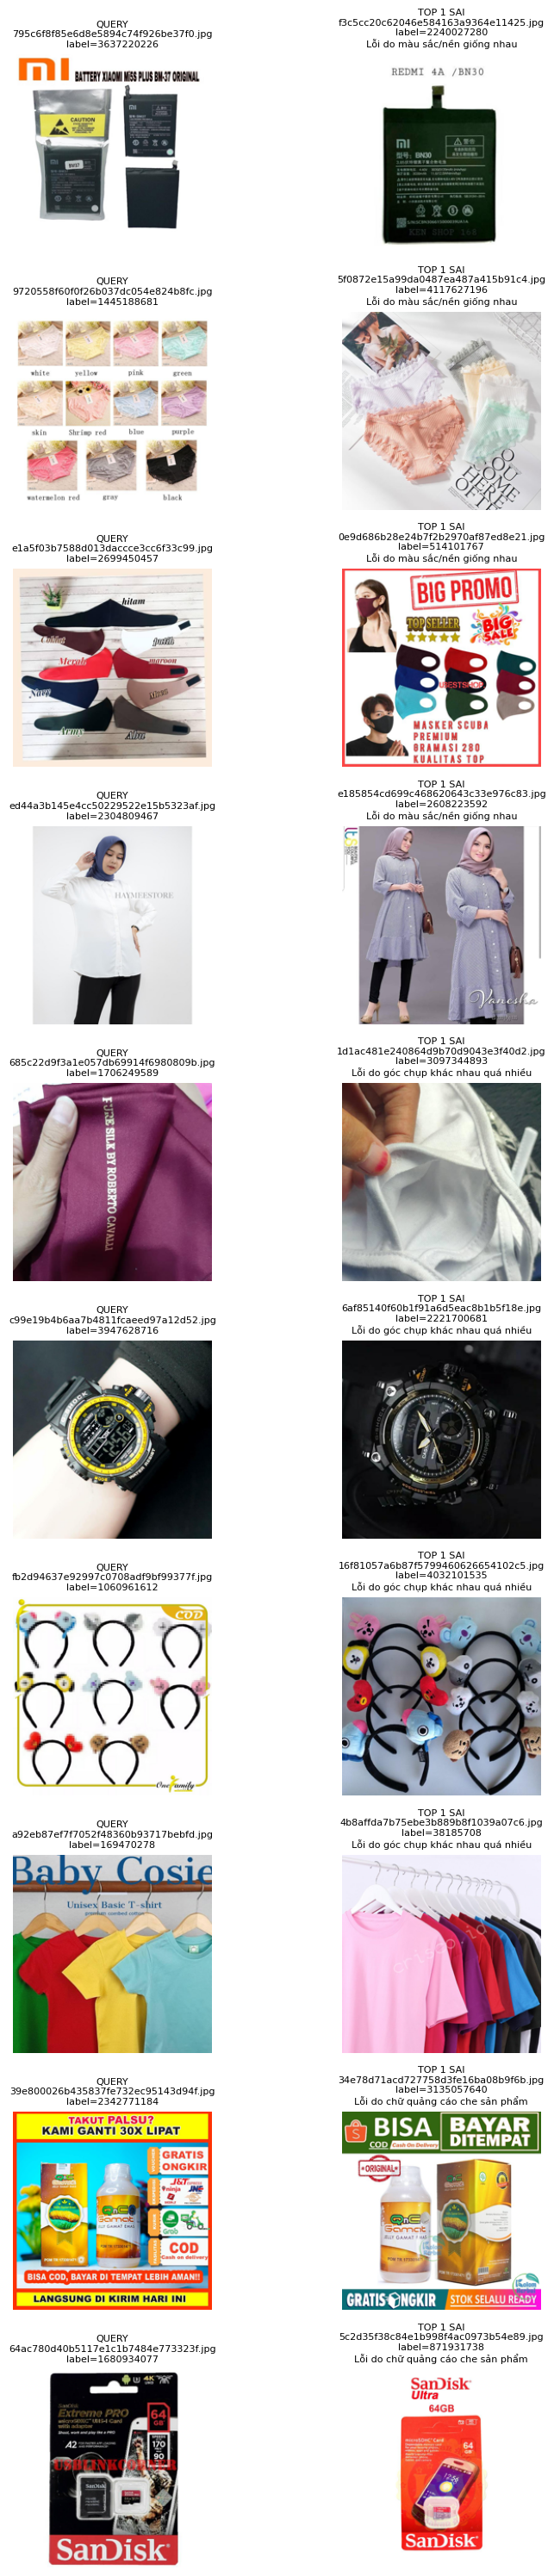

In [7]:
# ============================================================
# 7) Hiển thị 10 mẫu lỗi để kiểm tra trực quan
# ============================================================
def show_error_cases(df, max_cases=10):
    n = min(max_cases, len(df))
    if n == 0:
        print("Không có mẫu để hiển thị.")
        return

    fig, axes = plt.subplots(n, 2, figsize=(9, max(3, 3 * n)))
    if n == 1:
        axes = np.array([axes])

    for row_id, (_, row) in enumerate(df.head(n).iterrows()):
        q_img = load_rgb(row["query_path"], size=(224, 224))
        t_img = load_rgb(row["top1_path"], size=(224, 224)) if row["top1_path"] else Image.new("RGB", (224, 224), "white")

        axes[row_id, 0].imshow(q_img)
        axes[row_id, 0].set_title(
            f"QUERY\n{row['query_image']}\nlabel={row['label_query']}",
            fontsize=8
        )
        axes[row_id, 0].axis("off")

        axes[row_id, 1].imshow(t_img)
        axes[row_id, 1].set_title(
            f"TOP 1 SAI\n{row['top1_result']}\nlabel={row['label_top1']}\n{row['error_type']}",
            fontsize=8
        )
        axes[row_id, 1].axis("off")

    plt.tight_layout()
    plt.show()


show_error_cases(error_analysis_df, max_cases=10)


## Ghi chú chỉnh tay

Cột `error_type` và `lý do sai` đã được gợi ý tự động bằng heuristic ảnh. Trước khi nộp, nên nhìn 10 cặp ảnh phía trên và chỉnh lại CSV nếu có mẫu bị phân loại sai.

Ba nhóm hợp lệ:

1. `Lỗi do màu sắc/nền giống nhau`
2. `Lỗi do chữ quảng cáo che sản phẩm`
3. `Lỗi do góc chụp khác nhau quá nhiều`
